Filtros


### Mapa de filtros

| Grupo | Filtros |
|---|---|
| **Dominio espacial** | Convolución con PSF (Normal, Desenfocada, Aberración Esférica) |
| **Dominio frecuencial — ideales** | Pasa-Bajas (LPF), Pasa-Altas (HPF), Pasa-Bandas (BPF) |
| **Dominio frecuencial — suaves** | Gaussiano, Butterworth |
| **Filtros radiales y angulares** | Máscara radial, cuña angular |
| **Restauración — filtro inverso** | Filtro Inverso (naive) |
| **Restauración — filtro de Wiener** | Wiener SI, Wiener SV (sectores + interpolación) |
| **Restauración — regularización** | Tikhonov / TSVD |

---

### Estructura del notebook

1. Imports y configuración  
2. Fundamentos: el modelo de degradación  
3. Filtros en el dominio espacial (convolución con PSF)  
4. Filtros en el dominio de la frecuencia — ideales  
5. Filtros en el dominio de la frecuencia — suaves  
6. Filtros radiales y angulares  
7. Filtro Inverso  
8. Filtro de Wiener (Space Invariant)  
9. Filtro de Wiener Space-Variant (SV)  
10. Tikhonov / Regularización  
11. Tabla comparativa de métricas (PSNR / SSIM)  


## 1. Imports y configuración

Imagen de prueba: 512×512 px  |  dtype: float64
Rango: [0.000, 1.000]


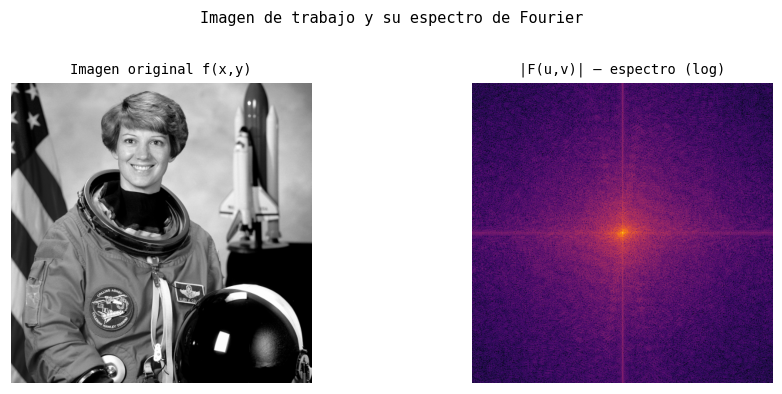

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LogNorm
from scipy import ndimage
from skimage import data, color, metrics
from skimage.transform import resize
import warnings
warnings.filterwarnings('ignore')

# ── Estilo ────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.titlesize': 9,
    'axes.labelsize': 8,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'font.family': 'monospace',
})

# ── Imagen de prueba: Lenna / camera ─────────────────────────
img_orig = color.rgb2gray(data.astronaut()).astype(np.float64)
img_orig = img_orig / img_orig.max()
M, N = img_orig.shape

print(f"Imagen de prueba: {M}×{N} px  |  dtype: {img_orig.dtype}")
print(f"Rango: [{img_orig.min():.3f}, {img_orig.max():.3f}]")

fig, ax = plt.subplots(1, 2, figsize=(9, 3.5))
ax[0].imshow(img_orig, cmap='gray', vmin=0, vmax=1)
ax[0].set_title("Imagen original f(x,y)"); ax[0].axis('off')
F = np.fft.fftshift(np.fft.fft2(img_orig))
ax[1].imshow(np.log1p(np.abs(F)), cmap='inferno')
ax[1].set_title("|F(u,v)| — espectro (log)"); ax[1].axis('off')
plt.suptitle("Imagen de trabajo y su espectro de Fourier", fontsize=10, y=1.01)
plt.tight_layout(); plt.show()


## 2. El modelo de degradación

Todos los filtros de este proyecto giran en torno al **modelo lineal de degradación**:

$$
g(x,y) = (f * h)(x,y) + n(x,y)
$$

| Símbolo | Significado |
|---|---|
| $f(x,y)$ | Imagen original (desconocida) |
| $h(x,y)$ | Función de Dispersión de Punto — **PSF** |
| $*$ | Convolución 2D |
| $n(x,y)$ | Ruido aditivo (generalmente gaussiano) |
| $g(x,y)$ | Imagen observada (degradada) |

En el **dominio de la frecuencia** (usando el Teorema de Convolución):

$$
G(u,v) = H(u,v) \cdot F(u,v) + N(u,v)
$$

El objetivo de todos los filtros de restauración es **estimar** $\hat{F}$ dado $G$ y $H$.

### Relación señal-ruido (SNR / NSR)

$$
K = \frac{S_N(u,v)}{S_F(u,v)} = \frac{\text{densidad espectral del ruido}}{\text{densidad espectral de la señal}}
$$

$K$ aparece como parámetro central en el filtro de Wiener.


In [ ]:
# ── Utilidades que usaremos en todo el notebook ───────────────

def make_gaussian_psf(shape, sigma):
    """PSF gaussiana normalizada centrada en el origen (para fft2)."""
    h = np.zeros(shape)
    cy, cx = shape[0]//2, shape[1]//2
    y, x = np.ogrid[-cy:shape[0]-cy, -cx:shape[1]-cx]
    kernel = np.exp(-(x**2 + y**2) / (2*sigma**2))
    kernel /= kernel.sum()
    # Rotar al origen para usar directamente con fft2
    h = np.roll(np.roll(kernel, -cy, axis=0), -cx, axis=1)
    return h

def degrade(img, psf, sigma_noise=0.01):
    """Aplica PSF + ruido gaussiano."""
    G = np.fft.fft2(img) * np.fft.fft2(psf)
    g = np.real(np.fft.ifft2(G))
    g = g + np.random.normal(0, sigma_noise, img.shape)
    return np.clip(g, 0, 1)

def psnr(ref, est):
    return metrics.peak_signal_noise_ratio(ref, np.clip(est,0,1), data_range=1.0)

def ssim(ref, est):
    return metrics.structural_similarity(ref, np.clip(est,0,1), data_range=1.0)

# ── Generar imagen degradada de referencia ────────────────────
np.random.seed(42)
psf_ref = make_gaussian_psf(img_orig.shape, sigma=3.0)
sigma_noise = 0.02
img_deg = degrade(img_orig, psf_ref, sigma_noise)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
axes[0].imshow(img_orig, cmap='gray', vmin=0, vmax=1); axes[0].set_title("f(x,y) — Original"); axes[0].axis('off')
axes[1].imshow(np.fft.fftshift(np.abs(np.fft.fft2(psf_ref))), cmap='hot')
axes[1].set_title("H(u,v) — OTF de PSF gaussiana (σ=3)"); axes[1].axis('off')
axes[2].imshow(img_deg, cmap='gray', vmin=0, vmax=1); axes[2].set_title(f"g(x,y) — Degradada  |  PSNR={psnr(img_orig,img_deg):.1f} dB"); axes[2].axis('off')
plt.suptitle("Modelo de degradación: g = f * h + n", fontsize=10, y=1.01)
plt.tight_layout(); plt.show()

results = {}  # Diccionario donde guardaremos PSNR/SSIM de cada filtro


## 3. Filtros en el dominio espacial — Convolución con PSF

La convolución con una PSF es el **filtro más básico** y al mismo tiempo
el origen del problema de restauración.

$$
g(x,y) = \int\!\int f(x',y') \, h(x-x', y-y') \, dx'\,dy'
$$

Implementada eficientemente mediante el **Teorema de Convolución**:

$$
g = \mathcal{F}^{-1}\{\mathcal{F}\{f\} \cdot \mathcal{F}\{h\}\}
$$

### PSFs del proyecto

| PSF | Modelo matemático | Efecto visual |
|---|---|---|
| **Normal (Airy)** | $(2J_1(r)/r)^2$ | Difracción leve |
| **Desenfocada** | Disco uniforme | Bordes borrosos |
| **Aberración esférica** | Gaussiana + halo ancho | Halos suaves |
| **Gaussiana** | $\exp(-r^2/2\sigma^2)$ | Suavizado isotrópico |
| **Astigmatismo** | Gaussiana elíptica | Bordes direccionales |


In [ ]:
# ── Definir PSFs del proyecto ─────────────────────────────────

def make_psf_at_center(shape, psf_fn, size=51):
    """Genera un kernel centrado en el origen para convolver con fft2."""
    ky = np.linspace(-size//2, size//2, size)
    kx = np.linspace(-size//2, size//2, size)
    KX, KY = np.meshgrid(kx, ky)
    kernel = psf_fn(KX, KY)
    if kernel.sum() > 0:
        kernel /= kernel.sum()
    # Crear arreglo del tamaño de la imagen y rotar kernel al origen
    h = np.zeros(shape)
    s = size // 2
    h[:size, :size] = kernel
    h = np.roll(np.roll(h, -s, axis=0), -s, axis=1)
    return h

from scipy.special import j1

def psf_normal(X, Y, r_cutoff=4.0):
    r = np.sqrt(X**2 + Y**2) * (np.pi / r_cutoff) + 1e-8
    return (2 * j1(r) / r)**2

def psf_desenfocada(X, Y, R=8):
    return (np.sqrt(X**2 + Y**2) <= R).astype(float)

def psf_aberracion_esf(X, Y, sigma_c=2.5, sigma_h=8, ratio=0.15):
    r2 = X**2 + Y**2
    core = np.exp(-r2 / (2*sigma_c**2))
    halo = np.exp(-r2 / (2*sigma_h**2))
    return core + ratio * halo

def psf_gaussiana(X, Y, sigma=4):
    return np.exp(-(X**2 + Y**2) / (2*sigma**2))

def psf_astigmatismo(X, Y, sx=2, sy=8):
    return np.exp(-(X**2/(2*sx**2) + Y**2/(2*sy**2)))

psf_defs = [
    ("Normal (Airy)",       lambda X,Y: psf_normal(X,Y)),
    ("Desenfocada",         lambda X,Y: psf_desenfocada(X,Y)),
    ("Aberración esférica", lambda X,Y: psf_aberracion_esf(X,Y)),
    ("Gaussiana σ=4",       lambda X,Y: psf_gaussiana(X,Y)),
    ("Astigmatismo",        lambda X,Y: psf_astigmatismo(X,Y)),
]

# ── Visualizar kernels + imagen convolucionada ─────────────────
fig, axes = plt.subplots(3, len(psf_defs), figsize=(16, 9))

for col, (name, fn) in enumerate(psf_defs):
    h = make_psf_at_center(img_orig.shape, fn)
    g = np.real(np.fft.ifft2(np.fft.fft2(img_orig) * np.fft.fft2(h)))
    g = np.clip(g, 0, 1)

    # Kernel 2D (zoom central)
    hshow = np.fft.fftshift(h)
    cy, cx = M//2, N//2; z=30
    kernel_zoom = hshow[cy-z:cy+z, cx-z:cx+z]
    axes[0, col].imshow(kernel_zoom, cmap='hot')
    axes[0, col].set_title(name, fontsize=8)
    axes[0, col].axis('off')

    # OTF
    H = np.fft.fftshift(np.abs(np.fft.fft2(h)))
    axes[1, col].imshow(np.log1p(H), cmap='inferno')
    axes[1, col].set_title("|H(u,v)| log", fontsize=7)
    axes[1, col].axis('off')

    # Imagen degradada
    axes[2, col].imshow(g, cmap='gray', vmin=0, vmax=1)
    axes[2, col].set_title(f"g = f*h  |  PSNR={psnr(img_orig,g):.1f}", fontsize=7)
    axes[2, col].axis('off')

axes[0,0].set_ylabel("Kernel h(x,y)", fontsize=8)
axes[1,0].set_ylabel("OTF H(u,v)", fontsize=8)
axes[2,0].set_ylabel("Imagen degradada", fontsize=8)

plt.suptitle("PSFs del proyecto: kernel 2D · OTF · efecto sobre la imagen", fontsize=10, y=1.01)
plt.tight_layout(); plt.show()


## 4. Filtros en el dominio de la frecuencia — Ideales

Diseñamos filtros directamente como **máscaras** sobre el espectro de Fourier.
La operación es:

$$
\hat{f}(x,y) = \mathcal{F}^{-1}\{ H(u,v) \cdot G(u,v) \}
$$

### 4.1 Filtro Pasa-Bajas ideal (LPF)

$$
H_{LP}(u,v) = \begin{cases} 1 & \text{si } r \leq r_c \\ 0 & \text{si } r > r_c \end{cases}
\quad \text{donde } r = \sqrt{u^2 + v^2}
$$

**Efecto:** conserva contenido de baja frecuencia → suaviza la imagen.  
**Problema:** corte abrupto produce artefactos de *ringing* (ondas de Gibbs).

### 4.2 Filtro Pasa-Altas ideal (HPF)

$$H_{HP}(u,v) = 1 - H_{LP}(u,v)$$

**Efecto:** enfatiza bordes y detalles finos, elimina fondo liso.

### 4.3 Filtro Pasa-Bandas ideal (BPF)

$$
H_{BP}(u,v) = \begin{cases} 1 & \text{si } r_1 \leq r \leq r_2 \\ 0 & \text{en otro caso} \end{cases}
$$

**Efecto:** aisla una banda de frecuencias; útil para eliminar ruido periódico.


In [ ]:
# ── Construcción de máscaras frecuenciales ────────────────────

u = np.fft.fftshift(np.fft.fftfreq(N)) * N
v = np.fft.fftshift(np.fft.fftfreq(M)) * M
UU, VV = np.meshgrid(u, v)
R = np.sqrt(UU**2 + VV**2)   # frecuencia radial

def apply_freq_filter(img, mask):
    F = np.fft.fftshift(np.fft.fft2(img))
    return np.real(np.fft.ifft2(np.fft.ifftshift(F * mask)))

# Tres radios de corte
radios = [20, 60, 120]
filter_types = [
    ("Pasa-Bajas (LPF)",  lambda rc: (R <= rc).astype(float)),
    ("Pasa-Altas (HPF)",  lambda rc: (R > rc).astype(float)),
    ("Pasa-Bandas (BPF)", lambda rc: ((R >= rc*0.4) & (R <= rc)).astype(float)),
]

fig, axes = plt.subplots(len(filter_types)+1, len(radios)+1, figsize=(14, 12))

# Fila 0: imagen original + espectro
F_orig = np.fft.fftshift(np.fft.fft2(img_orig))
axes[0,0].imshow(img_orig, cmap='gray'); axes[0,0].set_title("Original"); axes[0,0].axis('off')
axes[0,1].imshow(np.log1p(np.abs(F_orig)), cmap='inferno'); axes[0,1].set_title("|F| log"); axes[0,1].axis('off')
for j in range(2, len(radios)+1): axes[0,j].axis('off')

for row, (fname, mask_fn) in enumerate(filter_types, start=1):
    # Etiqueta
    axes[row, 0].text(0.5, 0.5, fname, transform=axes[row,0].transAxes,
                      ha='center', va='center', fontsize=9, fontweight='bold',
                      rotation=0, color='navy')
    axes[row, 0].axis('off')
    for col, rc in enumerate(radios, start=1):
        mask = mask_fn(rc)
        result = apply_freq_filter(img_orig, mask)
        axes[row, col].imshow(result, cmap='gray',
                              vmin=result.min(), vmax=result.max())
        axes[row, col].set_title(f"rc={rc}  PSNR={psnr(img_orig,result):.1f}", fontsize=7)
        axes[row, col].axis('off')

plt.suptitle("Filtros ideales en frecuencia — efecto sobre la imagen", fontsize=11, y=1.01)
plt.tight_layout(); plt.show()

# ── Demostración del ringing (artefacto de Gibbs) ─────────────
rc = 40
mask_lp = (R <= rc).astype(float)
result_ideal = apply_freq_filter(img_orig, mask_lp)

# Perfil horizontal central
row_center = M // 2
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3))
ax1.imshow(result_ideal, cmap='gray'); ax1.axhline(row_center, color='r', lw=0.8)
ax1.set_title(f"LPF ideal rc={rc} — artefactos de ringing"); ax1.axis('off')
ax2.plot(img_orig[row_center], label='Original', lw=0.8, color='gray')
ax2.plot(result_ideal[row_center], label='LPF ideal', lw=1, color='steelblue')
ax2.set_title("Perfil horizontal — oscilaciones de Gibbs"); ax2.legend(fontsize=8)
plt.tight_layout(); plt.show()


## 5. Filtros suaves — Gaussiano y Butterworth

Para evitar los artefactos de *ringing* del corte ideal, se usan
filtros con **transición gradual**.

### 5.1 Filtro Gaussiano

$$
H_G(u,v) = e^{-r^2 / (2 \sigma_f^2)}
$$

- Producto de gaussianas sigue siendo gaussiana (no hay *ringing*)  
- Su transformada inversa también es gaussiana → no introduce oscilaciones

### 5.2 Filtro Butterworth de orden $n$

$$
H_B(u,v) = \frac{1}{1 + \left(\frac{r}{r_c}\right)^{2n}}
$$

- $n=1$: transición muy suave  
- $n \to \infty$: se aproxima al filtro ideal (aparece *ringing*)  
- Control independiente de la frecuencia de corte $r_c$ y la pendiente $n$

> **Criterio de elección:** si el ruido es gaussiano, el filtro gaussiano es
> estadísticamente óptimo para suavizado. Butterworth permite ajustar
> la pendiente según las necesidades de la aplicación.


In [ ]:
# ── Filtros suaves ────────────────────────────────────────────

def gaussian_filter_freq(sigma_f):
    return np.exp(-(R**2) / (2 * sigma_f**2))

def butterworth_filter(rc, order):
    return 1.0 / (1 + (R / (rc + 1e-8))**(2*order))

# ── Comparar: ideal vs gaussiano vs butterworth ───────────────
sigma_gauss = [15, 40, 80]
orders_bw   = [1, 2, 5]
rc_bw       = 50

fig, axes = plt.subplots(3, 4, figsize=(15, 10))

for col, sg in enumerate(sigma_gauss):
    mask = gaussian_filter_freq(sg)
    res  = apply_freq_filter(img_orig, mask)
    axes[0, col+1].imshow(res, cmap='gray', vmin=0, vmax=1)
    axes[0, col+1].set_title(f"Gaussiano σ={sg}  PSNR={psnr(img_orig,res):.1f}", fontsize=7)
    axes[0, col+1].axis('off')

for col, n in enumerate(orders_bw):
    mask = butterworth_filter(rc_bw, n)
    res  = apply_freq_filter(img_orig, mask)
    axes[1, col+1].imshow(res, cmap='gray', vmin=0, vmax=1)
    axes[1, col+1].set_title(f"Butterworth n={n} rc={rc_bw}  PSNR={psnr(img_orig,res):.1f}", fontsize=7)
    axes[1, col+1].axis('off')

# Original en primera columna
for row in range(3):
    axes[row,0].imshow(img_orig, cmap='gray'); axes[row,0].set_title("Original"); axes[row,0].axis('off')

# Perfiles de los filtros en frecuencia
r_axis = np.linspace(0, N//2, 200)
axes[2,1].set_title("Perfiles H(r) — respuesta frecuencial", fontsize=8)
for sg in sigma_gauss:
    axes[2,1].plot(r_axis, np.exp(-r_axis**2/(2*sg**2)), label=f"Gauss σ={sg}")
for n in orders_bw:
    axes[2,1].plot(r_axis, 1/(1+(r_axis/(rc_bw+1e-8))**(2*n)), '--', label=f"BW n={n}")
axes[2,1].axvline(rc_bw, color='k', lw=0.7, ls=':')
axes[2,1].set_xlabel("Frecuencia radial r"); axes[2,1].set_ylabel("H(r)")
axes[2,1].legend(fontsize=6, ncol=2); axes[2,2].axis('off'); axes[2,3].axis('off')

axes[0,0].set_ylabel("Gaussiano", fontsize=9)
axes[1,0].set_ylabel("Butterworth", fontsize=9)
plt.suptitle("Filtros suaves: Gaussiano vs Butterworth", fontsize=11, y=1.01)
plt.tight_layout(); plt.show()

# ── Sin ringing: comparación directa ─────────────────────────
row_center = M // 2
ideal_res = apply_freq_filter(img_orig, (R <= rc_bw).astype(float))
gauss_res = apply_freq_filter(img_orig, gaussian_filter_freq(30))
bw_res    = apply_freq_filter(img_orig, butterworth_filter(rc_bw, 2))

fig, axes = plt.subplots(1, 3, figsize=(13, 3))
for ax, res, title in zip(axes, [ideal_res, gauss_res, bw_res],
                           ["Ideal (ringing)", "Gaussiano (sin ringing)", "Butterworth n=2"]):
    ax.plot(img_orig[row_center], color='lightgray', lw=0.7, label="original")
    ax.plot(res[row_center], lw=1, label=title)
    ax.set_title(title, fontsize=8); ax.legend(fontsize=7)
plt.suptitle("Perfil horizontal — comparación de artefactos de ringing", fontsize=10, y=1.02)
plt.tight_layout(); plt.show()


## 6. Filtros radiales y angulares

En el análisis de composición frecuencial, combinamos dos tipos de máscaras:

### 6.1 Máscara radial

Selecciona una **anillo** de frecuencias:

$$
H_{rad}(u,v) = \mathbf{1}[r_1 \leq r \leq r_2]
$$

Permite separar "qué tan gruesas" son las estructuras (escala).

### 6.2 Máscara angular (cuña)

Selecciona una **orientación** del espectro:

$$
H_{ang}(u,v) = \mathbf{1}\left[|\theta(u,v) - \theta_0| \leq \Delta\theta / 2\right]
\quad \text{con } \theta = \arctan(v/u)
$$

Como el espectro de imágenes reales es simétrico, también captura la
cuña opuesta $(\theta_0 + 180°)$.

**Aplicación:** identificar ondas senoidales direccionales que componen la imagen.

### 6.3 Mapa de energía 2D (ángulo × frecuencia)

$$
E(\theta_k, r_m) = \sum_{(u,v) \in \text{cuña}_{k,m}} |F(u,v)|^2
$$

Por el **Teorema de Parseval**, esto equivale a la energía real de esa
familia de ondas en la imagen espacial.


In [ ]:
# ── Eje angular ───────────────────────────────────────────────
THETA = np.arctan2(VV, UU)   # ángulo en radianes, [-π, π]

def mascara_angular(theta_0_deg, ancho_deg, radio_min=5):
    """Cuña angular centrada en theta_0, ancho total = ancho_deg.
       Captura automáticamente la cuña opuesta (espectro simétrico)."""    t0 = np.deg2rad(theta_0_deg)
    hw = np.deg2rad(ancho_deg / 2)
    diff = np.abs(np.angle(np.exp(1j*(THETA - t0))))
    diff_op = np.abs(np.angle(np.exp(1j*(THETA - t0 - np.pi))))
    mask = ((diff <= hw) | (diff_op <= hw)) & (R >= radio_min)
    return mask.astype(float)

def mascara_radial(r1, r2):
    return ((R >= r1) & (R <= r2)).astype(float)

# ── Visualización de ondas por orientación ───────────────────
angles = [0, 45, 90, 135]
ancho  = 20

fig, axes = plt.subplots(2, len(angles)+1, figsize=(14, 6))
axes[0,0].imshow(img_orig, cmap='gray'); axes[0,0].set_title("Original"); axes[0,0].axis('off')
F_s = np.fft.fftshift(np.fft.fft2(img_orig))
axes[1,0].imshow(np.log1p(np.abs(F_s)), cmap='inferno')
axes[1,0].set_title("|F| log"); axes[1,0].axis('off')

for col, ang in enumerate(angles, start=1):
    mask = mascara_angular(ang, ancho, radio_min=10)
    # Mostrar máscara
    axes[1,col].imshow(mask, cmap='Blues', vmin=0, vmax=1)
    axes[1,col].set_title(f"Máscara θ={ang}°", fontsize=7); axes[1,col].axis('off')
    # Componente reconstruida
    result = apply_freq_filter(img_orig, mask)
    axes[0,col].imshow(np.abs(result), cmap='gray')
    axes[0,col].set_title(f"Componente θ={ang}°", fontsize=7); axes[0,col].axis('off')

plt.suptitle("Filtrado angular: ondas por orientación", fontsize=10, y=1.01)
plt.tight_layout(); plt.show()

# ── Mapa de energía angular × radial ─────────────────────────
n_ang = 36
n_rad = 10
angulos  = np.linspace(-90, 90, n_ang, endpoint=False)
r_bordes = np.linspace(5, N//2, n_rad+1)
energia  = np.zeros((n_ang, n_rad))

for i, ang in enumerate(angulos):
    for j in range(n_rad):
        mask_a = mascara_angular(ang, 180/n_ang * 2, radio_min=0)
        mask_r = mascara_radial(r_bordes[j], r_bordes[j+1])
        mask   = mask_a * mask_r
        F_masked = np.fft.fftshift(np.fft.fft2(img_orig)) * mask
        energia[i,j] = np.sum(np.abs(F_masked)**2)

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(energia, aspect='auto', cmap='plasma', origin='lower',
               extent=[r_bordes[0], r_bordes[-1], angulos[0], angulos[-1]])
ax.set_xlabel("Frecuencia radial (px⁻¹)"); ax.set_ylabel("Orientación (°)")
ax.set_title("Mapa de energía 2D: |F|² por orientación y frecuencia radial")
plt.colorbar(im, ax=ax, label="Energía")
plt.tight_layout(); plt.show()


## 7. Filtro Inverso

El filtro inverso es la solución **naïve** al problema de restauración.
Despejando de $G = H \cdot F + N$:

$$
\hat{F}_{inv}(u,v) = \frac{G(u,v)}{H(u,v)}
$$

### ¿Por qué falla?

1. Cuando $H(u,v) \approx 0$ (frecuencias atenuadas por la PSF),
   la división **amplifica el ruido** de forma descontrolada.
2. Incluso con ruido mínimo, el resultado es **inestable**.

### Filtro inverso truncado

Una solución parcial: aplicar el inverso **solo cuando** $|H| > \epsilon$:

$$
\hat{F}_{tinv}(u,v) = \begin{cases}
G(u,v)/H(u,v) & \text{si } |H(u,v)| \geq \epsilon \\
0 & \text{en otro caso}
\end{cases}
$$

Esto mejora algo, pero sigue siendo inestable con ruido real.
El **filtro de Wiener** es la solución estadísticamente óptima.


In [ ]:
# ── Filtro Inverso ────────────────────────────────────────────

def filtro_inverso(g, h, epsilon=1e-3):
    G = np.fft.fft2(g)
    H = np.fft.fft2(h)
    # Dividir solo donde |H| > epsilon
    H_abs = np.abs(H)
    mask = H_abs >= epsilon
    F_hat = np.zeros_like(G, dtype=complex)
    F_hat[mask] = G[mask] / H[mask]
    return np.real(np.fft.ifft2(F_hat))

# Degradar con distintos niveles de ruido
sigmas = [0.001, 0.01, 0.05]
epsilons = [1e-4, 1e-3, 1e-2]

fig, axes = plt.subplots(len(sigmas), len(epsilons)+1, figsize=(14, 9))

psf_test = make_gaussian_psf(img_orig.shape, sigma=2.5)

for row, sn in enumerate(sigmas):
    g_test = degrade(img_orig, psf_test, sigma_noise=sn)
    axes[row,0].imshow(g_test, cmap='gray', vmin=0, vmax=1)
    axes[row,0].set_title(f"Degradada σn={sn}", fontsize=8)
    axes[row,0].set_ylabel(f"σ_ruido={sn}", fontsize=8)
    axes[row,0].axis('off')

    for col, eps in enumerate(epsilons, start=1):
        result = np.clip(filtro_inverso(g_test, psf_test, epsilon=eps), 0, 1)
        axes[row,col].imshow(result, cmap='gray', vmin=0, vmax=1)
        axes[row,col].set_title(f"ε={eps}  PSNR={psnr(img_orig,result):.1f}", fontsize=7)
        axes[row,col].axis('off')

plt.suptitle("Filtro Inverso: sensibilidad al ruido y al umbral ε", fontsize=10, y=1.01)
plt.tight_layout(); plt.show()

# Guardar resultado representativo
g_ref2 = degrade(img_orig, psf_ref, sigma_noise=0.01)
inv_result = np.clip(filtro_inverso(g_ref2, psf_ref, epsilon=1e-2), 0, 1)
results['Filtro Inverso (ε=0.01)'] = (psnr(img_orig, inv_result), ssim(img_orig, inv_result))
print(f"Filtro Inverso  →  PSNR={results['Filtro Inverso (ε=0.01)'][0]:.2f} dB  |  SSIM={results['Filtro Inverso (ε=0.01)'][1]:.4f}")


## 8. Filtro de Wiener (Space Invariant)

El filtro de Wiener es la **solución óptima** en el sentido del mínimo
error cuadrático medio (MMSE) bajo el modelo $G = HF + N$.

### Derivación

Minimizando $E\{|F - \hat{F}|^2\}$ con respecto al filtro lineal $W$:

$$
\hat{F}(u,v) = W(u,v) \cdot G(u,v)
$$

con:

$$
\boxed{W(u,v) = \frac{H^*(u,v)}{|H(u,v)|^2 + K}}
\quad , \quad K = \frac{S_N(u,v)}{S_F(u,v)}
$$

### Interpretación

- **Cuando $|H|^2 \gg K$** (buena SNR): $W \approx 1/H$ → actúa como filtro inverso.
- **Cuando $|H|^2 \ll K$** (mala SNR): $W \approx 0$ → suprime esas frecuencias.
- El parámetro $K$ es el **ratio ruido/señal** espectral.

### Variantes

| Variante | $K$ | Uso |
|---|---|---|
| Wiener estándar | Constante $K = \sigma_n^2 / \sigma_f^2$ | NSR estimado global |
| Wiener adaptativo | $K(u,v)$ variable | NSR espectral real |
| Wiener paramétrico | $K$ como hiperparámetro ajustado | Cuando se desconoce el NSR |


In [ ]:
# ── Filtro de Wiener (SI) ────────────────────────────────────

def wiener_filter(g, h, K):
    """Filtro de Wiener con K constante (NSR)."""
    G = np.fft.fft2(g)
    H = np.fft.fft2(h)
    H_conj = np.conj(H)
    W = H_conj / (np.abs(H)**2 + K)
    F_hat = W * G
    return np.real(np.fft.ifft2(F_hat))

# ── Efecto del parámetro K ────────────────────────────────────
g_test = degrade(img_orig, psf_ref, sigma_noise=0.02)

Ks = [1e-5, 1e-3, 1e-2, 0.1, 0.5]
fig, axes = plt.subplots(2, len(Ks)+1, figsize=(16, 6))

axes[0,0].imshow(img_orig, cmap='gray', vmin=0, vmax=1)
axes[0,0].set_title("Original"); axes[0,0].axis('off')
axes[1,0].imshow(g_test, cmap='gray', vmin=0, vmax=1)
axes[1,0].set_title("Degradada"); axes[1,0].axis('off')

psnr_vals = []
for col, K in enumerate(Ks, start=1):
    result = np.clip(wiener_filter(g_test, psf_ref, K), 0, 1)
    p = psnr(img_orig, result)
    psnr_vals.append(p)
    axes[0,col].imshow(result, cmap='gray', vmin=0, vmax=1)
    axes[0,col].set_title(f"K={K}  PSNR={p:.1f}", fontsize=7)
    axes[0,col].axis('off')
    # Diferencia con original
    diff = np.abs(img_orig - result)
    axes[1,col].imshow(diff, cmap='hot', vmin=0, vmax=0.3)
    axes[1,col].set_title(f"|error|  max={diff.max():.3f}", fontsize=7)
    axes[1,col].axis('off')

plt.suptitle("Filtro de Wiener SI: efecto del parámetro K (NSR)", fontsize=10, y=1.01)
plt.tight_layout(); plt.show()

# Curva PSNR vs K
fig, ax = plt.subplots(figsize=(7, 3))
ax.semilogx(Ks, psnr_vals, 'o-', color='steelblue', lw=2)
ax.set_xlabel("K (NSR)"); ax.set_ylabel("PSNR (dB)")
ax.set_title("PSNR en función del parámetro K — hay un óptimo")
ax.grid(True, alpha=0.4)
plt.tight_layout(); plt.show()

# Guardar mejor resultado
best_K = Ks[np.argmax(psnr_vals)]
best_result = np.clip(wiener_filter(g_test, psf_ref, best_K), 0, 1)
results['Wiener SI'] = (psnr(img_orig, best_result), ssim(img_orig, best_result))
print(f"Wiener SI (K={best_K})  →  PSNR={results['Wiener SI'][0]:.2f} dB  |  SSIM={results['Wiener SI'][1]:.4f}")


## 9. Filtro de Wiener Space-Variant (SV)

En el modelo SI asumimos $h(x,y)$ igual en toda la imagen.
Muchos sistemas reales tienen una **PSF que varía con la posición**:

$$
g(x,y) = \iint f(x',y') \, h(x,y;x',y') \, dx'dy' + n(x,y)
$$

### 9.1 Restauración por sectores

1. Dividir la imagen en $S \times S$ sectores solapados
2. Estimar la PSF local $h_s$ para cada sector
3. Aplicar Wiener local en cada sector
4. Combinar con ventanas gaussianas para suavizar los bordes

$$
\hat{f}(x,y) = \frac{\sum_s w_s(x,y) \cdot \hat{f}_s(x,y)}{\sum_s w_s(x,y)}
$$

### 9.2 Interpolación de filtros de Wiener

En lugar de mezclar imágenes restauradas, interpolamos directamente los filtros:

1. Calcular $W_k(u,v)$ en $K$ posiciones de referencia
2. Para cualquier punto $(x,y)$, interpolar por distancia inversa (IDW):

$$
W(u,v;x,y) = \sum_k w_k(x,y) \cdot W_k(u,v)
\quad,\quad w_k = \frac{1/d_k}{\sum_j 1/d_j}
$$

3. Aplicar el filtro interpolado a la región correspondiente

> **Ventaja:** evita artefactos de borde entre sectores; transición suave.


In [ ]:
# ── Generar campo de PSF variable (sigma crece del centro al borde) ───

def sigma_field(shape, sigma_min=1.5, sigma_max=5.0):
    """Campo de sigma: mínimo en el centro, máximo en las esquinas."""    cy, cx = shape[0]//2, shape[1]//2
    y, x = np.ogrid[:shape[0], :shape[1]]
    r = np.sqrt((x-cx)**2 + (y-cy)**2)
    r_norm = r / r.max()
    return sigma_min + (sigma_max - sigma_min) * r_norm

sigma_map = sigma_field(img_orig.shape)

# ── Degradar SV (por bloques) ──────────────────────────────────
def degrade_sv(img, sigma_map, block=64, sigma_noise=0.015):
    g = np.zeros_like(img)
    M, N = img.shape
    weight = np.zeros_like(img)
    for y in range(0, M, block//2):
        for x in range(0, N, block//2):
            y1,y2 = y, min(y+block, M)
            x1,x2 = x, min(x+block, N)
            sigma_local = sigma_map[y1:y2, x1:x2].mean()
            patch = img[y1:y2, x1:x2]
            h_local = make_gaussian_psf(patch.shape, sigma=sigma_local)
            G = np.fft.fft2(patch) * np.fft.fft2(h_local)
            conv = np.real(np.fft.ifft2(G))
            win = np.outer(np.hanning(y2-y1), np.hanning(x2-x1))
            g[y1:y2, x1:x2]      += conv * win
            weight[y1:y2, x1:x2] += win
    g /= (weight + 1e-8)
    g += np.random.normal(0, sigma_noise, img.shape)
    return np.clip(g, 0, 1)

img_deg_sv = degrade_sv(img_orig, sigma_map)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(sigma_map, cmap='hot')
axes[0].set_title("Campo σ(x,y) — PSF varía con la posición"); axes[0].axis('off')
plt.colorbar(axes[0].images[0], ax=axes[0], label="σ (px)")
axes[1].imshow(img_orig, cmap='gray'); axes[1].set_title("Original"); axes[1].axis('off')
axes[2].imshow(img_deg_sv, cmap='gray')
axes[2].set_title(f"Degradada SV  PSNR={psnr(img_orig,img_deg_sv):.1f} dB"); axes[2].axis('off')
plt.tight_layout(); plt.show()

# ── Restauración SV por sectores ──────────────────────────────
def restore_sv_sectors(g, sigma_map, K=0.01, n_sectors=4, overlap=0.5):
    M, N = g.shape
    f_hat = np.zeros_like(g)
    weight_total = np.zeros_like(g)
    step = int(M / n_sectors * (1 - overlap))
    block = M // n_sectors + int(M // n_sectors * overlap)

    for i in range(n_sectors):
        for j in range(n_sectors):
            y1 = min(i * step, M - block)
            x1 = min(j * step, N - block)
            y2 = min(y1 + block, M)
            x2 = min(x1 + block, N)

            patch_g = g[y1:y2, x1:x2]
            sigma_loc = sigma_map[y1:y2, x1:x2].mean()
            h_loc = make_gaussian_psf(patch_g.shape, sigma=sigma_loc)

            H = np.fft.fft2(h_loc)
            G = np.fft.fft2(patch_g)
            W = np.conj(H) / (np.abs(H)**2 + K)
            restored = np.real(np.fft.ifft2(W * G))

            win = np.outer(np.hanning(y2-y1), np.hanning(x2-x1))
            f_hat[y1:y2, x1:x2]      += restored * win
            weight_total[y1:y2, x1:x2] += win

    return np.clip(f_hat / (weight_total + 1e-8), 0, 1)

# Comparar SI vs SV
sigma_global = sigma_map.mean()
h_global = make_gaussian_psf(img_orig.shape, sigma=sigma_global)
result_si = np.clip(wiener_filter(img_deg_sv, h_global, K=0.01), 0, 1)
result_sv = restore_sv_sectors(img_deg_sv, sigma_map, K=0.01, n_sectors=4)

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for ax, img, title in zip(axes,
        [img_orig, img_deg_sv, result_si, result_sv],
        ["Original", f"Degradada SV
PSNR={psnr(img_orig,img_deg_sv):.1f}",
         f"Wiener SI
PSNR={psnr(img_orig,result_si):.1f}",
         f"Wiener SV (sectores)
PSNR={psnr(img_orig,result_sv):.1f}"]):
    ax.imshow(img, cmap='gray', vmin=0, vmax=1)
    ax.set_title(title, fontsize=8); ax.axis('off')
plt.suptitle("Restauración SV: Wiener SI vs Wiener por sectores", fontsize=10, y=1.01)
plt.tight_layout(); plt.show()

results['Wiener SV (sectores)'] = (psnr(img_orig, result_sv), ssim(img_orig, result_sv))
results['Wiener SI (sobre SV)'] = (psnr(img_orig, result_si), ssim(img_orig, result_si))


## 10. Regularización de Tikhonov

El filtro de Wiener es un caso especial de un marco más general:
la **regularización de Tikhonov**.

### Problema de mínimos cuadrados regularizado

$$
\hat{f} = \arg\min_f \left\{ \|g - Hf\|^2 + \lambda \|Lf\|^2 \right\}
$$

| Término | Significado |
|---|---|
| $\|g - Hf\|^2$ | Fidelidad al dato (ajuste a la imagen degradada) |
| $\lambda \|Lf\|^2$ | Regularización (preferencia a soluciones suaves) |
| $L$ | Operador de regularización |
| $\lambda$ | Peso de la regularización |

### Solución en frecuencia

Con $L$ = Laplaciano o identidad:

$$
\hat{F}(u,v) = \frac{H^*(u,v)}{|H(u,v)|^2 + \lambda |L(u,v)|^2} \cdot G(u,v)
$$

**Conexión con Wiener:** si $L = I$ (identidad), $\lambda = K = S_N/S_F$ → idéntico al filtro de Wiener.

### Casos especiales

| $L$ | Efecto |
|---|---|
| Identidad $I$ | Penaliza amplitud → equivale a Wiener |
| Laplaciano $\nabla^2$ | Penaliza variaciones rápidas → imagen más suave |
| Gradiente $\nabla$ | Penaliza bordes → TV regularización |


In [ ]:
# ── Tikhonov con diferentes operadores L ─────────────────────

def laplacian_kernel(shape):
    """Laplaciano en frecuencia."""    h_lap = np.zeros(shape)
    h_lap[0,0]  =  4
    h_lap[0,1]  = -1; h_lap[0,-1] = -1
    h_lap[1,0]  = -1; h_lap[-1,0] = -1
    return np.fft.fft2(h_lap)

def tikhonov_filter(g, h, lam, L_freq=None):
    """Filtro de Tikhonov generalizado.
    Si L_freq=None usa L=I (equivale a Wiener)."""    G = np.fft.fft2(g)
    H = np.fft.fft2(h)
    if L_freq is None:
        L_freq = np.ones_like(H)
    W = np.conj(H) / (np.abs(H)**2 + lam * np.abs(L_freq)**2)
    return np.real(np.fft.ifft2(W * G))

g_noisy = degrade(img_orig, psf_ref, sigma_noise=0.03)
L_lap   = laplacian_kernel(img_orig.shape)
L_ident = np.ones(img_orig.shape, dtype=complex)

lambdas = [1e-4, 1e-3, 1e-2]
fig, axes = plt.subplots(3, len(lambdas)+1, figsize=(14, 10))

titles_row = ["Original", "Degradada", "Tikhonov (L=I)", "Tikhonov (L=Lap)"]
for row, (L, name) in enumerate([(None, "L=I (≡ Wiener)"),
                                   (L_lap, "L=Laplaciano")]):
    axes[row, 0].imshow(img_orig if row==0 else g_noisy, cmap='gray', vmin=0, vmax=1)
    axes[row, 0].set_title("Original" if row==0 else "Degradada"); axes[row,0].axis('off')
    axes[row, 0].set_ylabel(name, fontsize=8)
    for col, lam in enumerate(lambdas, start=1):
        result = np.clip(tikhonov_filter(g_noisy, psf_ref, lam, L), 0, 1)
        axes[row,col].imshow(result, cmap='gray', vmin=0, vmax=1)
        axes[row,col].set_title(f"λ={lam}  PSNR={psnr(img_orig,result):.1f}", fontsize=7)
        axes[row,col].axis('off')

# Fila de diferencias (Wiener - Laplaciano)
axes[2,0].imshow(img_orig, cmap='gray'); axes[2,0].set_title("Ref"); axes[2,0].axis('off')
for col, lam in enumerate(lambdas, start=1):
    r_i = np.clip(tikhonov_filter(g_noisy, psf_ref, lam, L_ident), 0, 1)
    r_l = np.clip(tikhonov_filter(g_noisy, psf_ref, lam, L_lap), 0, 1)
    diff = r_i - r_l
    axes[2,col].imshow(diff, cmap='RdBu', vmin=-0.15, vmax=0.15)
    axes[2,col].set_title(f"Diff (I−Lap) λ={lam}", fontsize=7); axes[2,col].axis('off')
    axes[2,0].set_ylabel("Diferencia I vs Lap", fontsize=8)

plt.suptitle("Regularización de Tikhonov: L=Identidad vs L=Laplaciano", fontsize=10, y=1.01)
plt.tight_layout(); plt.show()

best_tik = np.clip(tikhonov_filter(g_noisy, psf_ref, 1e-3, L_lap), 0, 1)
results['Tikhonov (L=Lap)'] = (psnr(img_orig, best_tik), ssim(img_orig, best_tik))
print(f"Tikhonov Laplaciano  →  PSNR={results['Tikhonov (L=Lap)'][0]:.2f} dB  |  SSIM={results['Tikhonov (L=Lap)'][1]:.4f}")


## 11. Comparación final de todos los filtros

Resumen de métricas PSNR y SSIM sobre la misma imagen degradada
(PSF gaussiana σ=3, ruido σ=0.02).


In [ ]:
# ── Tabla comparativa ────────────────────────────────────────
print("╔══════════════════════════════════════╦═════════════╦════════════╗")
print("║ Filtro                               ║  PSNR (dB)  ║    SSIM    ║")
print("╠══════════════════════════════════════╬═════════════╬════════════╣")
for name, (p, s) in sorted(results.items(), key=lambda x: -x[1][0]):
    print(f"║ {name:<36} ║   {p:>7.2f}   ║  {s:.6f}  ║")
print("╚══════════════════════════════════════╩═════════════╩════════════╝")

# ── Gráfico de barras ─────────────────────────────────────────
names = list(results.keys())
psnrs = [results[n][0] for n in names]
ssims = [results[n][1] for n in names]
order = np.argsort(psnrs)[::-1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(names)))

bars1 = ax1.barh([names[i] for i in order], [psnrs[i] for i in order],
                  color=[colors[i] for i in order], edgecolor='white')
ax1.set_xlabel("PSNR (dB)"); ax1.set_title("PSNR por filtro (mayor = mejor)")
ax1.bar_label(bars1, fmt="%.1f dB", padding=3, fontsize=7)

bars2 = ax2.barh([names[i] for i in order], [ssims[i] for i in order],
                  color=[colors[i] for i in order], edgecolor='white')
ax2.set_xlabel("SSIM"); ax2.set_title("SSIM por filtro (mayor = mejor)")
ax2.bar_label(bars2, fmt="%.4f", padding=3, fontsize=7)

plt.suptitle("Comparación de todos los filtros del proyecto", fontsize=11, y=1.01)
plt.tight_layout(); plt.show()


## Resumen conceptual

| Filtro | Requiere PSF | Maneja ruido | Complejidad | Mejor para |
|---|---|---|---|---|
| **Convolución PSF** | ✓ (directa) | ✗ | Baja | Modelar degradación |
| **LPF / HPF / BPF** | ✗ | Parcialmente | Baja | Análisis frecuencial |
| **Gaussiano / Butterworth** | ✗ | Sí (suave) | Baja | Suavizado sin ringing |
| **Radial / Angular** | ✗ | ✗ | Baja | Descomposición en orientaciones |
| **Filtro Inverso** | ✓ | ✗ | Baja | Solo con ruido mínimo |
| **Wiener SI** | ✓ | ✓ | Media | PSF uniforme en toda la imagen |
| **Wiener SV (sectores)** | ✓ (local) | ✓ | Alta | PSF variable, bordes bruscos |
| **Wiener SV (interp.)** | ✓ (local) | ✓ | Alta | PSF variable, transición suave |
| **Tikhonov** | ✓ | ✓ | Media | Control explícito de suavidad |

### Cadena completa del proyecto

```
Imagen original f(x,y)
        │
        ▼  [Convolución con PSF → filtro espacial]
Imagen degradada g(x,y) = f*h + n
        │
        ▼  [Análisis: LPF/HPF/BPF/Radial/Angular]
Comprensión del espectro
        │
        ▼  [Restauración: Wiener / Tikhonov]
Estimación f̂(x,y)
        │
        ▼  [Evaluación: PSNR / SSIM]
Métricas de calidad
```
